In [537]:
import mesa
print("You are using mesa version: " + mesa.__version__)

from mesa import Agent, Model
import random
from mesa.datacollection import DataCollector
import matplotlib.pyplot as plt

You are using mesa version: 3.0.3


In [538]:
class Klant(Agent):
    def __init__(self, model, man, leeftijd, inkomen, stad):
        super().__init__(model)
        self.man = man
        self.leeftijd = leeftijd
        self.inkomen = inkomen
        self.stad = stad

        self.milieubewustzijn = self.milieu()
        self.geldbewustzijn = self.geld()



    def milieu(self):
        factor_geslacht = 0.20
        factor_leeftijd= 0.35
        factor_inkomen= 0.30
        factor_stad= 0.25

        milieubewustzijn = 0

        if self.man:
            gemiddelde_MB = 0.55
            standaard_deviatie = 0.5
            MB_man = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_man = max(0, min(1, MB_man))
            milieubewustzijn += MB_man * factor_geslacht
        else:
            gemiddelde_MB = 0.60
            standaard_deviatie = 0.5
            MB_vrouw = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_vrouw = max(0, min(1, MB_vrouw))
            milieubewustzijn += MB_vrouw * factor_geslacht


        if self.leeftijd < 30:
            gemiddelde_MB = 0.60
            standaard_deviatie = 0.5
            MB_onder30 = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_onder30 = max(0, min(1, MB_onder30))
            milieubewustzijn += MB_onder30 * factor_leeftijd
        else:
            gemiddelde_MB = 0.55
            standaard_deviatie = 0.5
            MB_boven30 = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_boven30 = max(0, min(1, MB_boven30))
            milieubewustzijn += MB_boven30 * factor_leeftijd


        if self.inkomen:    #inkomen is > 3000 euro
            gemiddelde_MB = 0.60
            standaard_deviatie = 0.5
            MB_hooginkomen = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_hooginkomen = max(0, min(1, MB_hooginkomen))
            milieubewustzijn += MB_hooginkomen * factor_inkomen
        else:
            gemiddelde_MB = 0.50
            standaard_deviatie = 0.2
            MB_laaginkomen = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_laaginkomen = max(0, min(1, MB_laaginkomen))
            milieubewustzijn += MB_laaginkomen * factor_inkomen


        if self.stad:
            gemiddelde_MB = 0.60
            standaard_deviatie = 0.5
            MB_stad = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_stad = max(0, min(1, MB_stad))
            milieubewustzijn += MB_stad * factor_stad
        else:
            gemiddelde_MB = 0.50
            standaard_deviatie = 0.5
            MB_platteland = self.random.normalvariate(gemiddelde_MB, standaard_deviatie)
            MB_platteland = max(0, min(1, MB_platteland))
            milieubewustzijn += MB_platteland * factor_stad

        return milieubewustzijn



    def geld(self):
        factor_geslacht = 0.10
        factor_leeftijd= 0.25
        factor_inkomen= 0.50
        factor_stad= 0.25

        geldbewustzijn = 0

        if self.man:
            gemiddelde_GB = 0.70
            standaard_deviatie = 1
            GB_man = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_man = max(0, min(1, GB_man))
            geldbewustzijn += GB_man * factor_geslacht
        else:
            gemiddelde_GB = 0.80
            standaard_deviatie = 1
            GB_vrouw = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_vrouw = max(0, min(1, GB_vrouw))
            geldbewustzijn += GB_vrouw * factor_geslacht


        if self.leeftijd < 30:
            gemiddelde_GB = 0.80
            standaard_deviatie = 1
            GB_onder30 = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_onder30 = max(0, min(1, GB_onder30))
            geldbewustzijn += GB_onder30 * factor_leeftijd
        else:
            gemiddelde_GB = 0.65
            standaard_deviatie = 1
            GB_boven30 = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_boven30 = max(0, min(1, GB_boven30))
            geldbewustzijn += GB_boven30 * factor_leeftijd


        if self.inkomen:    #inkomen is > 3000 euro
            gemiddelde_GB = 0.60
            standaard_deviatie = 1
            GB_hooginkomen = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_hooginkomen = max(0, min(1, GB_hooginkomen))
            geldbewustzijn += GB_hooginkomen * factor_inkomen
        else:
            gemiddelde_GB = 0.90
            standaard_deviatie = 1
            GB_laaginkomen = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_laaginkomen = max(0, min(1, GB_laaginkomen))
            geldbewustzijn += GB_laaginkomen * factor_inkomen


        if self.stad:
            gemiddelde_GB = 0.55
            standaard_deviatie = 1
            GB_stad = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_stad = max(0, min(1,GB_stad))
            geldbewustzijn += GB_stad * factor_stad
        else:
            gemiddelde_GB = 0.70
            standaard_deviatie = 1
            GB_platteland = self.random.normalvariate(gemiddelde_GB, standaard_deviatie)
            GB_platteland = max(0, min(1, GB_platteland))
            geldbewustzijn += GB_platteland * factor_stad

        return geldbewustzijn



    def nieuw_milieubewustzijn(self):
        basis_MB = self.milieu()

        other_agent = self.random.choice(self.model.agents_list)
        vriend_milieubewustzijn = other_agent.milieubewustzijn

        nieuw_MB = (basis_MB * 0.7) + (vriend_milieubewustzijn * 0.2) + (self.milieubewustzijn * 0.1)

        return nieuw_MB

    def nieuw_geldbewustzijn(self):
        basis_GB = self.geld()

        other_agent = self.random.choice(self.model.agents_list)
        vriend_geldbewustzijn = other_agent.geldbewustzijn

        nieuw_GB = (basis_GB * 0.7) + (vriend_geldbewustzijn * 0.2) + (self.geldbewustzijn * 0.1)

        return nieuw_GB



    def scheidingsgedrag(self):
        if self.milieubewustzijn > self.model.drempelwaarde_milieu:
            self.model.gescheiden_dozen += 1
        else:
            self.model.niet_gescheiden_dozen += 1

    def retourgedrag(self):
        if self.model.statie_list:
            huidig_krat = self.model.random.choice(self.model.statie_list)

            if self.geldbewustzijn > self.model.drempelwaarde_geld:
                self.model.geretourneerde_kratten += 1
                huidig_krat.gebruik()
            else:
                self.model.niet_geretourneerde_kratten += 1     #iemand laat zn krat thuis/gooit hem weg, dus wordt verwijdert uit de lijst
                self.model.verwijder_krat(huidig_krat)

                willekeurige_levensduur = max (1, int(self.random.normalvariate(50, 5)))

                nieuwe_krat = Statie(self.model, levensduur=willekeurige_levensduur)
                self.model.statie_list.append(nieuwe_krat)



    def step(self):
        if self.model.statiebeleid:
            self.geldbewustzijn = self.nieuw_geldbewustzijn()
            self.retourgedrag()

        else:
            self.milieubewustzijn = self.nieuw_milieubewustzijn()
            self.scheidingsgedrag()

In [539]:
class Statie(Agent):
    def __init__(self, model, levensduur):
        super().__init__(model)
        self.levensduur = levensduur
        #self.gemiddelde_levensduur = 50
        #self.standaart_deviatie = 5

        #self.levensduur = max (1, int(self.random.normalvariate(self.gemiddelde_levensduur, self.standaart_deviatie)))

    def gebruik(self):
        self.levensduur -= 1
        if self.levensduur == 0:
            self.model.kratten_uit_omloop += 1
            self.model.verwijder_krat(self)
            self.model.maak_krat()


In [540]:
class HelloFresh(Model):
    def __init__(self, num_agents, statiebeleid, drempelwaarde_milieu, drempelwaarde_geld, scenario_1):
        super().__init__()
        self.num_agents = num_agents
        self.statiebeleid = statiebeleid
        self.drempelwaarde_milieu = drempelwaarde_milieu
        self.drempelwaarde_geld = drempelwaarde_geld
        self.scenario_1 = scenario_1
        self.agents_list = []
        self.statie_list = []

        self.afval_deze_week = 0
        self.cumulatief_afval = 0

        self.gescheiden_dozen = 0
        self.niet_gescheiden_dozen = 0
        self.geretourneerde_kratten = 0
        self.niet_geretourneerde_kratten = 0
        self.kratten_uit_omloop = 0

        self.cumulatief_kratten_uit_omloop = 0

        self.datacollector = DataCollector(
            model_reporters={
                "Afval Deze Week": "afval_deze_week",
                "Cumulatief Afval": "cumulatief_afval",
                "Gescheiden Dozen": "gescheiden_dozen",
                "Niet Gescheiden Dozen": "niet_gescheiden_dozen",
                "Geretourneerde Kratten": "geretourneerde_kratten",
                "Niet Geretourneerde Kratten": "niet_geretourneerde_kratten",
                "Kratten Uit Omloop": "kratten_uit_omloop",
                "Cumulatief Kratten Uit Omloop": "cumulatief_kratten_uit_omloop",
                "Gemiddeld Milieubewustzijn": lambda m: sum(a.milieubewustzijn for a in m.agents_list) / len(m.agents_list),
                "Gemiddeld Geldbewustzijn": lambda m: sum(a.geldbewustzijn for a in m.agents_list) / len(m.agents_list),
            }
        )
        if scenario_1:  #klanten van HelloFresh
            for i in range(self.num_agents):
                willekeurig_geslacht = self.random.random() < 0.25
                willekeurige_leeftijd = self.random.randint(25, 65)
                willekeurig_inkomen = self.random.random() < 0.46
                willekeurig_stad = self.random.random() < 0.83

                a = Klant(
                    self,
                    man=willekeurig_geslacht,
                    leeftijd=willekeurige_leeftijd,
                    inkomen=willekeurig_inkomen,
                    stad=willekeurig_stad)
                self.agents_list.append(a)

        else:           #heel Nederland
            for i in range(self.num_agents):
                willekeurig_geslacht = self.random.random() < ...
                willekeurige_leeftijd = self.random.randint(..., ...)
                willekeurig_inkomen = self.random.random() < ...
                willekeurig_stad = self.random.random() < ...

                a = Klant(
                    self,
                    man=willekeurig_geslacht,
                    leeftijd=willekeurige_leeftijd,
                    inkomen=willekeurig_inkomen,
                    stad=willekeurig_stad)
            self.agents_list.append(a)

        if self.statiebeleid:
            for i in range(self.num_agents):
                willekeurige_levensduur = max (1, int(self.random.normalvariate(50, 5)))

                s = Statie(self, levensduur=willekeurige_levensduur)
                self.statie_list.append(s)

    def verwijder_krat(self, krat):
        if krat in self.statie_list:
            self.statie_list.remove(krat)

    def maak_krat(self):
        willekeurige_levensduur = max (1, int(self.random.normalvariate(50, 5)))

        s = Statie(self, levensduur=willekeurige_levensduur)
        self.statie_list.append(s)

    def afval(self):    ### HEEL BELANGRIJK!!! ###
        factor_gescheiden_dozen = 1
        factor_niet_gescheiden_dozen = 2
        factor_kratten_uit_omloop = 8
        factor_niet_geretourneerde_kratten = 8

        self.afval_deze_week = (
                (self.gescheiden_dozen * factor_gescheiden_dozen) +
                (self.niet_gescheiden_dozen * factor_niet_gescheiden_dozen) +
                (self.kratten_uit_omloop * factor_kratten_uit_omloop) +
                (self.niet_geretourneerde_kratten * factor_niet_geretourneerde_kratten))
        self.cumulatief_afval += self.afval_deze_week

    def step(self):
        self.gescheiden_dozen = 0
        self.niet_gescheiden_dozen = 0
        self.geretourneerde_kratten = 0
        self.niet_geretourneerde_kratten = 0
        self.kratten_uit_omloop = 0

        for agent in self.agents_list:
            agent.step()

        self.afval()

        self.datacollector.collect(self)

        print ("De afvalwaarde per week is: ", self.afval_deze_week)

        print ("Het aantal gescheiden dozen is: ", self.gescheiden_dozen)
        print ("Het aantal niet_gescheiden dozen is: ", self.niet_gescheiden_dozen)
        print ("Het aantal geretourneerde_kratten is: ", self.geretourneerde_kratten)
        print ("Het aantal niet_geretourneerde_kratten is: ", self.niet_geretourneerde_kratten)
        print ("Het aantal kratten dat kapot is gegaan is: ", self.kratten_uit_omloop)

In [541]:
model = HelloFresh(50, True, 0.25, 0.25, True)

for i in range(150):
    model.step()

De afvalwaarde per week is:  8
Het aantal gescheiden dozen is:  0
Het aantal niet_gescheiden dozen is:  0
Het aantal geretourneerde_kratten is:  49
Het aantal niet_geretourneerde_kratten is:  1
Het aantal kratten dat kapot is gegaan is:  0
De afvalwaarde per week is:  0
Het aantal gescheiden dozen is:  0
Het aantal niet_gescheiden dozen is:  0
Het aantal geretourneerde_kratten is:  50
Het aantal niet_geretourneerde_kratten is:  0
Het aantal kratten dat kapot is gegaan is:  0
De afvalwaarde per week is:  8
Het aantal gescheiden dozen is:  0
Het aantal niet_gescheiden dozen is:  0
Het aantal geretourneerde_kratten is:  49
Het aantal niet_geretourneerde_kratten is:  1
Het aantal kratten dat kapot is gegaan is:  0
De afvalwaarde per week is:  8
Het aantal gescheiden dozen is:  0
Het aantal niet_gescheiden dozen is:  0
Het aantal geretourneerde_kratten is:  49
Het aantal niet_geretourneerde_kratten is:  1
Het aantal kratten dat kapot is gegaan is:  0
De afvalwaarde per week is:  0
Het aanta

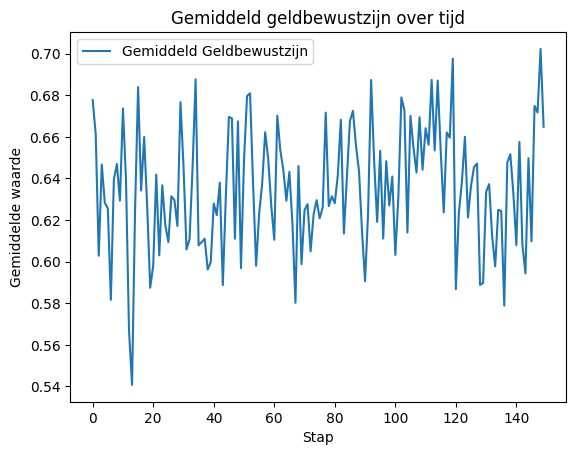

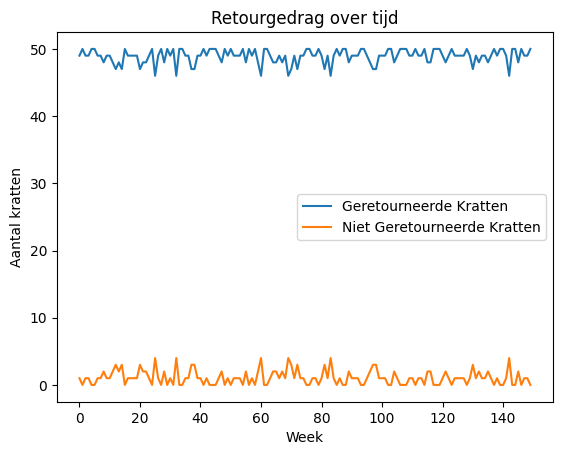

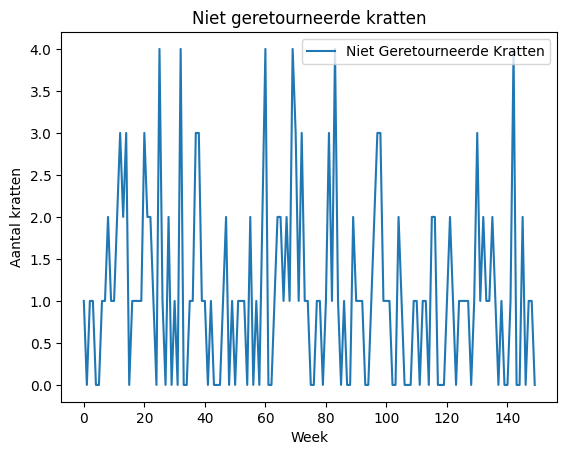

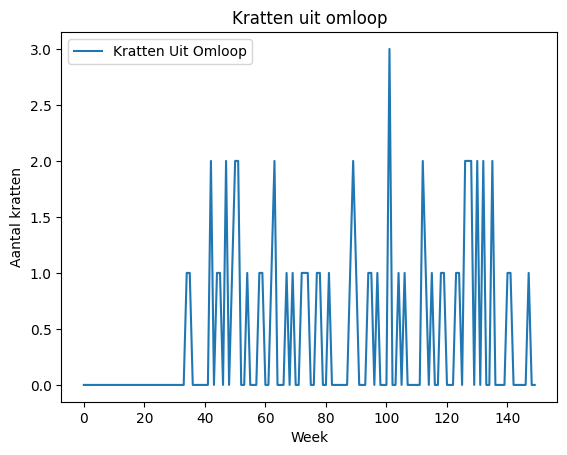

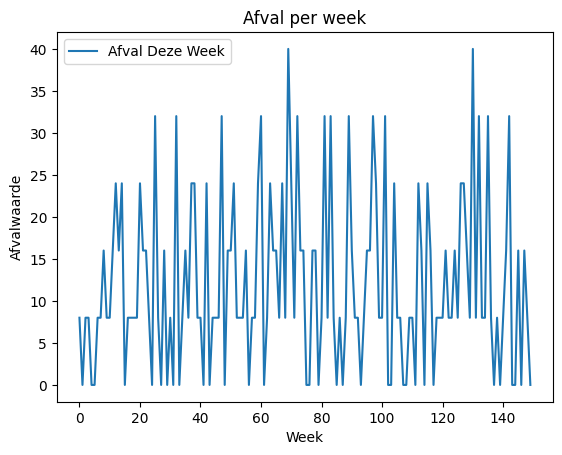

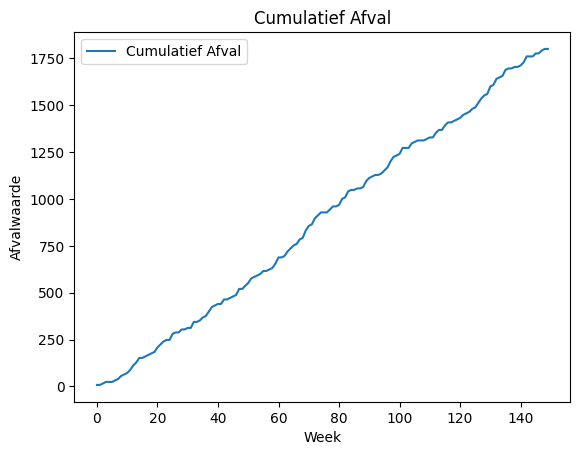

In [542]:
results = model.datacollector.get_model_vars_dataframe()

if model.statiebeleid:
    results["Gemiddeld Geldbewustzijn"].plot()
    plt.title("Gemiddeld geldbewustzijn over tijd")
    plt.xlabel("Stap")
    plt.ylabel("Gemiddelde waarde")
    plt.legend()
    plt.show()

    results[["Geretourneerde Kratten", "Niet Geretourneerde Kratten"]].plot()
    plt.title("Retourgedrag over tijd")
    plt.xlabel("Week")
    plt.ylabel("Aantal kratten")
    plt.legend()
    plt.show()

    results["Niet Geretourneerde Kratten"].plot()
    plt.title("Niet geretourneerde kratten")
    plt.xlabel("Week")
    plt.ylabel("Aantal kratten")
    plt.legend()
    plt.show()

    results["Kratten Uit Omloop"].plot()
    plt.title("Kratten uit omloop")
    plt.xlabel("Week")
    plt.ylabel("Aantal kratten")
    plt.legend()
    plt.show()

else:
    results["Gemiddeld Milieubewustzijn"].plot()
    plt.title("Gemiddeld milieubewustzijn over tijd")
    plt.xlabel("Stap")
    plt.ylabel("Gemiddelde waarde")
    plt.legend()
    plt.show()

    results[["Gescheiden Dozen", "Niet Gescheiden Dozen"]].plot()
    plt.title("Scheidingsgedrag over tijd")
    plt.xlabel("Week")
    plt.ylabel("Aantal dozen")
    plt.legend()
    plt.show()

    results["Niet Gescheiden Dozen"].plot()
    plt.title("Niet gescheiden dozen")
    plt.xlabel("Week")
    plt.ylabel("Aantal dozen")
    plt.legend()
    plt.show()

results["Afval Deze Week"].plot()
plt.title("Afval per week")
plt.xlabel("Week")
plt.ylabel("Afvalwaarde")
plt.legend()
plt.show()

results["Cumulatief Afval"].plot()
plt.title("Cumulatief Afval")
plt.xlabel("Week")
plt.ylabel("Afvalwaarde")
plt.legend()
plt.show()